# Bloque 3 — Procesamiento masivo y computación distribuida

**Módulo:** Extracción, Transformación y Carga de Datos desde Fuentes Múltiples (5104)
**Unidad Didáctica:** UD1 — Tipología y características de las fuentes de datos
**Duración estimada:** ~6 horas
**Curso académico:** 2026-2027

---

### Contenidos de este bloque

| Epígrafe | Contenido |
|----------|-----------|
| **3.1** | Paradigmas de procesamiento: batch, micro-batch y streaming |
| **3.2** | Procesamiento en chunks con pandas |
| **3.3** | Dask: paralelismo transparente en local |
| **3.4** | Apache Spark: arquitectura y modelo MapReduce |
| **3.5** | Particionado, shuffling y optimización |
| **3.6** | Aprendizaje online y streaming con scikit-learn |

### Criterios de evaluación asociados
> **(CE g)** Se han identificado las principales herramientas y plataformas para el procesamiento
> masivo de datos orientado al aprendizaje automático.
> **(CE h)** Se han aplicado técnicas de procesamiento distribuido y en tiempo real a conjuntos
> de datos de gran volumen.

---


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import subprocess
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Librerias cargadas correctamente.")


Librerias cargadas correctamente.


---
## 3.1 Paradigmas de procesamiento masivo

Cuando el volumen de datos supera la RAM de una sola máquina —o cuando los datos llegan
de forma continua— necesitamos estrategias de **procesamiento masivo**.
Los tres paradigmas principales son:

| Paradigma | Latencia típica | Caso de uso en ML | Herramientas |
|-----------|----------------|-------------------|--------------|
| **Batch** | Minutos / horas | ETL nocturno, reentrenamiento periódico | Spark, Hadoop |
| **Micro-batch** | Segundos / minutos | Dashboards casi-tiempo-real | Spark Structured Streaming |
| **Streaming** | Milisegundos | Detección de fraude en tiempo real | Flink, Kafka Streams |

**Regla práctica para ML:** ¿cuándo necesitas el resultado?

- **Ya** → streaming (latencia < 1 s)
- **En minutos** → micro-batch
- **Puedo esperar horas** → batch (más sencillo y más barato)

El diagrama siguiente muestra cómo varía el flujo de datos en cada paradigma.


![Paradigmas de procesamiento masivo](imagenes/b3_paradigmas.png)

---
## 3.2 Procesamiento en chunks con pandas

La técnica más sencilla para procesar ficheros que no caben en RAM es
**leer el CSV en trozos (chunks)**. `pd.read_csv(..., chunksize=N)` devuelve un
iterador que carga N filas en cada iteración:

```python
for chunk in pd.read_csv('grande.csv', chunksize=50_000):
    # chunk es un DataFrame con 50 000 filas
    procesar(chunk)
```

**Limitaciones:**
- Solo funciona para operaciones **acumulables** (suma, conteo, mín, máx).
- Operaciones globales como la mediana o el ordenado completo no son acumulables
  de forma directa.
- Un solo hilo: no aprovecha múltiples núcleos de CPU.

Vamos a generar un CSV sintético grande y aplicarle una agregación por chunks.


In [2]:
N_FILAS = 600_000
print(f"Generando CSV sintetico con {N_FILAS:,} filas...")

np.random.seed(42)
df_grande = pd.DataFrame({
    'id':          range(N_FILAS),
    'sensor':      np.random.choice(['A', 'B', 'C', 'D'], N_FILAS),
    'valor':       np.random.randn(N_FILAS),
    'temperatura': np.random.uniform(15.0, 85.0, N_FILAS),
    'activo':      np.random.choice([True, False], N_FILAS),
})

RUTA_CSV = Path('datos_grandes.csv')
df_grande.to_csv(RUTA_CSV, index=False)
tam_mb = RUTA_CSV.stat().st_size / 1e6
print(f"CSV guardado: {RUTA_CSV}  ({tam_mb:.1f} MB)")
del df_grande


Generando CSV sintetico con 600,000 filas...
CSV guardado: datos_grandes.csv  (31.9 MB)


In [3]:
# Calcular la media de 'valor' por 'sensor' sin cargar todo el fichero en RAM.
# Acumulamos suma y conteo para derivar la media al final.

t0 = time.perf_counter()

acumulado = {}
filas_totales = 0

for chunk in pd.read_csv(RUTA_CSV, chunksize=50_000):
    for sensor, grupo in chunk.groupby('sensor'):
        if sensor not in acumulado:
            acumulado[sensor] = {'suma': 0.0, 'n': 0}
        acumulado[sensor]['suma'] += grupo['valor'].sum()
        acumulado[sensor]['n']    += len(grupo)
    filas_totales += len(chunk)

t_chunk = time.perf_counter() - t0
# Calcular la media final si valor es distinto de cero para evitar división por cero
# Evitar división por cero
medias = {k: (v['suma'] / v['n']) for k, v in acumulado.items() if v['n'] > 0}

print(f"Procesadas {filas_totales:,} filas en {t_chunk:.3f} s")
print("Media de 'valor' por sensor:")
for sensor in sorted(medias):
    print(f"  Sensor {sensor}: {medias[sensor]:+.4f}")


Procesadas 600,000 filas en 0.642 s
Media de 'valor' por sensor:
  Sensor A: -0.0016
  Sensor B: -0.0036
  Sensor C: +0.0002
  Sensor D: -0.0003


---
## 3.3 Dask: paralelismo transparente en local

**Dask** extiende la API de pandas y NumPy para trabajar con datasets mayores que la RAM,
**en paralelo** y sin necesitar un clúster (aunque escala a clúster si hace falta).

### pandas chunks vs Dask

| Característica | pandas chunks | Dask |
|---------------|--------------|------|
| Paralelismo multi-núcleo | No | Sí (automático) |
| API compatible con pandas | Sí | Sí (casi idéntica) |
| Evaluación diferida (lazy) | No | Sí |
| Escalado a clúster | No | Sí (Dask Distributed) |
| Requiere instalación extra | No | `pip install dask` |

### Evaluación diferida

En Dask las operaciones **no se ejecutan hasta que llamas a `.compute()`**.
Primero construye un grafo de tareas y luego lo ejecuta de forma paralela y optimizada.

```python
ddf = dd.read_csv('grande.csv')                     # lazy, no lee nada
resultado = ddf.groupby('sensor')['valor'].mean()   # define la operacion
medias = resultado.compute()                        # ejecuta el grafo
```

El diagrama siguiente muestra la arquitectura interna de Dask.


![Arquitectura de Dask](imagenes/b3_dask.png)

In [4]:
r = subprocess.run(
    ['pip', 'install', 'dask', '--quiet', '--break-system-packages'],
    capture_output=True, text=True
)
print("dask instalado." if r.returncode == 0 else r.stderr[:300])

import dask
import dask.array as da
print(f"Version de Dask: {dask.__version__}")

# Arrays Dask con evaluacion diferida
x = da.random.random((10_000, 1_000), chunks=(1_000, 200))
print(f"Array Dask: shape={x.shape}  chunk=(1000, 200)")
print(f"Tipo del objeto: {type(x)}")

media_cols = x.mean(axis=0)
print(f"Primeras 5 medias de columnas: {media_cols.compute()[:5].round(4)}")
print("(.compute() ejecuto los calculos en paralelo sobre todos los chunks)")


dask instalado.
Version de Dask: 2026.8.0
Array Dask: shape=(10000, 1000)  chunk=(1000, 200)
Tipo del objeto: <class 'dask.array.core.Array'>
Primeras 5 medias de columnas: [0.4999 0.5024 0.4977 0.5016 0.4998]
(.compute() ejecuto los calculos en paralelo sobre todos los chunks)


### El panel de control de Dask: dónde se ve el paralelismo

Al crear un `Client()`, Dask levanta en nuestro equipo un **clúster local**: un *scheduler* (planificador), que reparte el trabajo, y varios *workers*, que lo ejecutan. Con 8 núcleos suelen salir 4 workers de 2 hilos cada uno. El scheduler publica un panel web en la dirección que imprime `client.dashboard_link`, normalmente `http://127.0.0.1:8787/status`.

Para verlo trabajar seguimos tres pasos:

1. Ejecutamos la celda del `Client()` **antes que cualquier cálculo con Dask**. Lo que se calcula antes (como el array de la celda anterior) usa el planificador por defecto y no aparece en el panel.
2. Abrimos el panel en el navegador y lo colocamos al lado del cuaderno.
3. Ejecutamos la celda siguiente y miramos el panel mientras corre: con este CSV tarda alrededor de un segundo.

| Gráfica del panel | Qué muestra | Qué veremos con 8 particiones |
|---|---|---|
| **Task Stream** | Una fila por hilo de cada worker; cada barra es una tarea | Ocho barras de `read_csv` que arrancan a la vez en filas distintas: cada trozo del CSV se lee en un núcleo |
| **Progress** | Tareas terminadas de cada tipo | `read_csv 8/8`, luego las agregaciones parciales y, al final, la combinación |
| **Graph** (pestaña) | El grafo de tareas | Ocho ramas que se juntan en una: cada trozo calcula su suma y su recuento por sensor, y una última tarea los combina |

La combinación final es **una sola tarea**: esa parte ya no es paralela.

> **⚠️ Error común:** `dd.read_csv()` corta el fichero en bloques de unos 64 MB. Nuestro `datos_grandes.csv` ocupa 32 MB, así que sin indicar nada sale **una sola partición** y el panel muestra una única fila trabajando. Por eso fijamos `blocksize="4MB"`, que da unas 8 particiones, una por núcleo.

> **📝 Nota del Profesor:** si el cálculo va demasiado rápido para seguirlo, prueba `blocksize="1MB"` (unas 32 particiones): verás cómo cada hilo va cogiendo un trozo nuevo en cuanto termina el anterior.

In [ ]:
from dask.distributed import Client

# Inicia un clúster local: un scheduler y varios workers en este mismo equipo
client = Client()
print(client)                  # cuántos workers, hilos y memoria tiene el clúster
print(client.dashboard_link)   # URL del panel: ábrela en el navegador ANTES de ejecutar la celda siguiente

In [ ]:
import dask.dataframe as dd

# Averiguamos cuantos nucleos tiene el sistema para paralelizar los calculos
import multiprocessing
nucleos = multiprocessing.cpu_count()
print(f"Numero de nucleos disponibles: {nucleos}")  


t0 = time.perf_counter()
# blocksize="4MB": el CSV (32 MB) se parte en unas 8 particiones, una por núcleo.
# Sin él, Dask usa bloques de ~64 MB y el fichero entero cabe en UNA sola partición: no hay paralelismo.
ddf = dd.read_csv(RUTA_CSV, blocksize="4MB")
t_read = time.perf_counter() - t0
print(f"dd.read_csv(): {t_read:.4f} s  (lazy, no ha leido el fichero)")
print(f"Tipo:          {type(ddf)}")
print(f"Columnas:      {list(ddf.columns)}")
print(f"Particiones:   {ddf.npartitions}")

t0 = time.perf_counter()
medias_dask = ddf.groupby('sensor')['valor'].mean().compute()
t_dask = time.perf_counter() - t0
print(f"Media por sensor (Dask) en {t_dask:.3f} s")
print(medias_dask.sort_index())


In [7]:
from dask import delayed

@delayed
def leer_fragmento(seed, n):
    np.random.seed(seed)
    return np.random.randn(n)

@delayed
def calcular_media(arr):
    return float(np.mean(arr))

@delayed
def combinar(lista_medias):
    return float(np.mean(lista_medias))

# Construir el grafo (no ejecuta nada todavia)
fragmentos   = [leer_fragmento(i, 10_000) for i in range(8)]
medias_frag  = [calcular_media(f) for f in fragmentos]
media_global = combinar(medias_frag)

print(f"Tipo de media_global: {type(media_global)}  (no calculado todavia)")

t0 = time.perf_counter()
resultado = media_global.compute()
t_delay = time.perf_counter() - t0
print(f"Media calculada: {resultado:.6f}  (en {t_delay:.3f} s, paralelo)")


Tipo de media_global: <class 'dask.delayed.Delayed'>  (no calculado todavia)
Media calculada: -0.006149  (en 0.140 s, paralelo)


---
## 3.4 Apache Spark: arquitectura y modelo MapReduce

**Apache Spark** es el motor de procesamiento distribuido más usado en proyectos de ML
a gran escala. A diferencia de Dask (un nodo o clúster Python), Spark está diseñado para
clústeres de miles de nodos y petabytes de datos.

### Arquitectura

```
Driver Program (SparkContext / SparkSession)
    |
    +-- Cluster Manager (YARN / Kubernetes / Standalone)
            |
            +-- Worker 1:  Executor  [Task][Task][Cache]
            +-- Worker 2:  Executor  [Task][Task][Cache]
            +-- Worker N:  Executor  [Task][Task][Cache]
```

### Abstracciones principales

| Abstracción | Descripción | Evaluación |
|-------------|-------------|-----------|
| **RDD** (Resilient Distributed Dataset) | Colección distribuida, tolerante a fallos | Lazy |
| **DataFrame** | RDD con esquema tipado, optimizable con Catalyst | Lazy |
| **Dataset** | DataFrame tipado en compilación (Scala/Java) | Lazy |

### Transformaciones vs Acciones

- **Transformaciones** (lazy): `map`, `filter`, `groupBy`, `join` → definen el grafo DAG
- **Acciones** (disparan la ejecución): `count`, `collect`, `show`, `write` → ejecutan el grafo

> **Instalación:** PySpark requiere Java 8/11 y el paquete `pip install pyspark`.
> En desarrollo local se usa el modo `local[*]` (todos los núcleos de la máquina).

El diagrama siguiente muestra la arquitectura completa de un clúster Spark.


![Arquitectura de Apache Spark](imagenes/b3_spark.png)

In [8]:
# Simulacion del modelo MapReduce con Python puro
# (Spark hace exactamente esto, distribuido entre maquinas)
from functools import reduce as f_reduce
from collections import defaultdict

ventas = [
    ('Madrid',    1200), ('Barcelona', 850), ('Madrid',    950),
    ('Sevilla',   430),  ('Barcelona', 760), ('Sevilla',   520),
    ('Madrid',    1100), ('Valencia',  670), ('Valencia',  390),
    ('Barcelona', 910),  ('Madrid',    780), ('Valencia',  540),
]

print("=== Paso 1: MAP ===")
mapeado = list(map(lambda v: (v[0], v[1]), ventas))
print(f"  {mapeado[:4]} ...")

print()
print("=== Paso 2: SHUFFLE / GROUP BY ===")
agrupado = defaultdict(list)
for ciudad, importe in mapeado:
    agrupado[ciudad].append(importe)
for ciudad, importes in sorted(agrupado.items()):
    print(f"  {ciudad}: {importes}")

print()
print("=== Paso 3: REDUCE ===")
reducido = {ciudad: f_reduce(lambda a, b: a + b, importes)
            for ciudad, importes in agrupado.items()}
for ciudad, total in sorted(reducido.items()):
    print(f"  {ciudad:12s}: {total:,} euros")

print()
print("--- En PySpark seria: ---")
print("  sc = SparkContext()")
print("  rdd = sc.parallelize(ventas)")
print("  resultado = rdd.reduceByKey(lambda a, b: a + b).collect()")


=== Paso 1: MAP ===
  [('Madrid', 1200), ('Barcelona', 850), ('Madrid', 950), ('Sevilla', 430)] ...

=== Paso 2: SHUFFLE / GROUP BY ===
  Barcelona: [850, 760, 910]
  Madrid: [1200, 950, 1100, 780]
  Sevilla: [430, 520]
  Valencia: [670, 390, 540]

=== Paso 3: REDUCE ===
  Barcelona   : 2,520 euros
  Madrid      : 4,030 euros
  Sevilla     : 950 euros
  Valencia    : 1,600 euros

--- En PySpark seria: ---
  sc = SparkContext()
  rdd = sc.parallelize(ventas)
  resultado = rdd.reduceByKey(lambda a, b: a + b).collect()


---
## 3.5 Particionado, shuffling y optimización

El **particionado** determina cómo se distribuyen los datos entre los nodos del clúster.
Una mala estrategia de particionado es la causa más frecuente de rendimiento pobre.

### Estrategias de particionado

| Estrategia | Cómo asigna datos | Cuándo usarla |
|------------|-------------------|---------------|
| **Hash** | `hash(clave) % N_particiones` | Joins y groupBy sobre clave de alta cardinalidad |
| **Rango** | Ordena y divide en intervalos iguales | OrderBy, ventanas temporales |
| **Round-robin** | Distribución circular aleatoria | Cargas iniciales, sin clave de join |
| **Custom** | Función definida por el usuario | Por fecha, región geográfica, etc. |

### El shuffle: el cuello de botella

El **shuffle** ocurre cuando Spark redistribuye datos entre particiones (en un `groupBy` o `join`).
Es costoso porque requiere serializar, transferir por red y ordenar en destino.

**Truco práctico:** en un join repetido, usa `broadcast join` para la tabla pequeña y evita
el shuffle de la tabla grande.

El diagrama muestra cómo tres estrategias asignan los mismos datos a las particiones.


![Estrategias de particionado de datos](imagenes/b3_particionado.png)

In [9]:
# Benchmark: pandas chunks vs Dask
import warnings
warnings.filterwarnings('ignore')

print("Benchmark: pandas-chunks vs Dask")
print(f"Dataset: {RUTA_CSV.name}  ({RUTA_CSV.stat().st_size / 1e6:.1f} MB)")
print("-" * 52)

# --- pandas por chunks ---
t0 = time.perf_counter()
acc = {}
for chunk in pd.read_csv(RUTA_CSV, chunksize=50_000):
    sub = chunk[chunk['activo'] == True]
    for s, g in sub.groupby('sensor'):
        if s not in acc:
            acc[s] = 0.0
        acc[s] += g['valor'].sum()
t_pd = time.perf_counter() - t0
print(f"pandas chunks:  {t_pd:.3f} s")
for s in sorted(acc):
    print(f"  Sensor {s}: {acc[s]:+.2f}")

print()

# --- Dask ---
import dask.dataframe as dd
t0 = time.perf_counter()
ddf2 = dd.read_csv(RUTA_CSV, blocksize="4MB")   # ~8 particiones, como en el apartado 3.3
res_dask = (ddf2[ddf2['activo'] == True]
              .groupby('sensor')['valor']
              .sum()
              .compute())
t_dask = time.perf_counter() - t0
print(f"Dask:           {t_dask:.3f} s")
print(res_dask.sort_index())
print()
print(f"Factor Dask vs pandas-chunks: {t_pd / t_dask:.2f}x")
print("(Dask usa multiples nucleos; pandas-chunks usa uno solo)")


Benchmark: pandas-chunks vs Dask
Dataset: datos_grandes.csv  (31.9 MB)
----------------------------------------------------


pandas chunks:  1.059 s
  Sensor A: -206.72
  Sensor B: -293.21
  Sensor C: +233.74
  Sensor D: +72.51

Dask:           0.845 s
sensor
A   -206.715773
B   -293.212060
C    233.739464
D     72.505630
Name: valor, dtype: float64

Factor Dask vs pandas-chunks: 1.25x
(Dask usa multiples nucleos; pandas-chunks usa uno solo)


---
## 3.6 Aprendizaje online y streaming con scikit-learn

El **aprendizaje online** permite actualizar el modelo **incrementalmente** con cada mini-lote
de datos, sin necesidad de acceder a todo el dataset de una vez.

### ¿Cuándo usar aprendizaje online?

- Los datos llegan en tiempo real (logs, sensores IoT, transacciones)
- El dataset es demasiado grande para caber en RAM
- El patrón en los datos puede cambiar con el tiempo (**concept drift**)

### API `partial_fit` en scikit-learn

| Estimador | Tipo |
|-----------|------|
| `SGDClassifier` | Clasificación (SVM lineal, Regresión Logística) |
| `SGDRegressor` | Regresión lineal |
| `MiniBatchKMeans` | Clustering incremental |
| `IncrementalPCA` | Reducción de dimensionalidad |
| `StandardScaler` | Normalización incremental |

El diagrama siguiente muestra el pipeline completo de streaming con aprendizaje online.


![Pipeline de streaming con aprendizaje online](imagenes/b3_streaming.png)

In [10]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)

N_EVENTOS  = 20_000
LOTE       = 500
N_FEATURES = 6

clf    = SGDClassifier(loss='log_loss', max_iter=1, tol=None, random_state=42)
scaler = StandardScaler()

acuracidades = []
tiempos_lote = []

print("Simulacion de streaming con aprendizaje online")
print(f"Total eventos: {N_EVENTOS:,}  |  Tamano de lote: {LOTE}")
print("-" * 56)

for i, inicio in enumerate(range(0, N_EVENTOS, LOTE)):
    t_lote = time.perf_counter()

    X_lote = np.random.randn(LOTE, N_FEATURES)
    y_lote = (X_lote[:, 0] + X_lote[:, 1] + X_lote[:, 2] > 0).astype(int)

    scaler.partial_fit(X_lote)
    X_sc = scaler.transform(X_lote)

    clf.partial_fit(X_sc, y_lote, classes=[0, 1])

    acc = accuracy_score(y_lote, clf.predict(X_sc))
    acuracidades.append(acc)
    tiempos_lote.append(time.perf_counter() - t_lote)

    if i % 8 == 0:
        print(f"  Lote {i + 1:3d}  |  Eventos: {inicio + LOTE:6,}  |  acc = {acc:.3f}")

print("-" * 56)
print(f"Accuracy media:    {np.mean(acuracidades):.4f}")
print(f"Accuracy final:    {acuracidades[-1]:.4f}")
print(f"Tiempo medio/lote: {np.mean(tiempos_lote) * 1000:.2f} ms")
print(f"Throughput:        {LOTE / np.mean(tiempos_lote):,.0f} eventos/segundo")


Simulacion de streaming con aprendizaje online
Total eventos: 20,000  |  Tamano de lote: 500
--------------------------------------------------------
  Lote   1  |  Eventos:    500  |  acc = 0.930
  Lote   9  |  Eventos:  4,500  |  acc = 0.992
  Lote  17  |  Eventos:  8,500  |  acc = 0.984
  Lote  25  |  Eventos: 12,500  |  acc = 0.994
  Lote  33  |  Eventos: 16,500  |  acc = 0.984
--------------------------------------------------------
Accuracy media:    0.9806
Accuracy final:    0.9960
Tiempo medio/lote: 8.52 ms
Throughput:        58,659 eventos/segundo


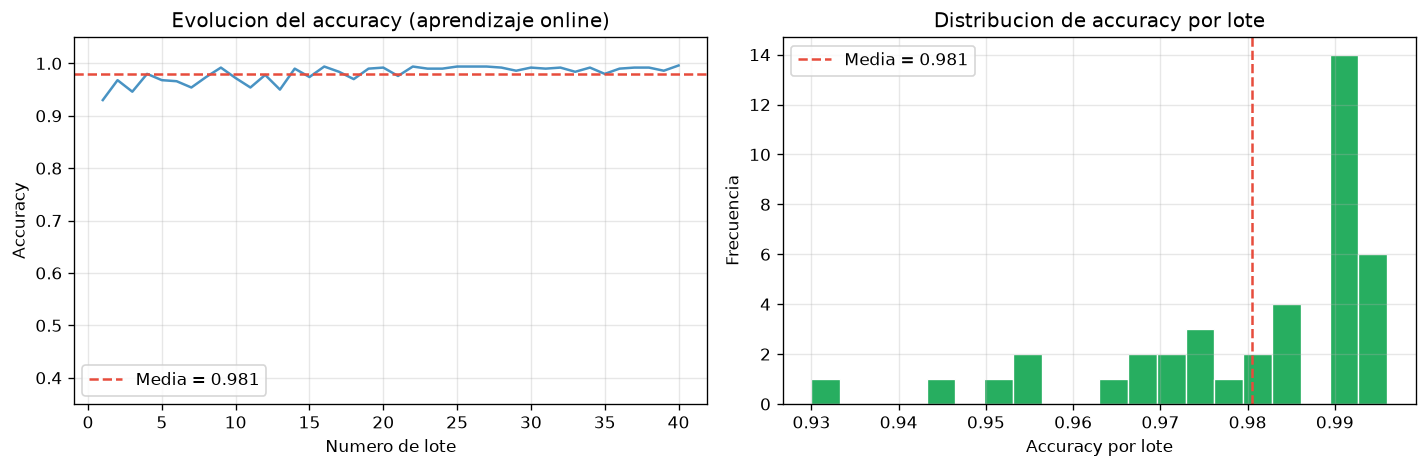

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
lotes = list(range(1, len(acuracidades) + 1))

ax1.plot(lotes, acuracidades, color='#2980b9', linewidth=1.5, alpha=0.85)
ax1.axhline(np.mean(acuracidades), color='#e74c3c', linestyle='--', linewidth=1.5,
            label=f'Media = {np.mean(acuracidades):.3f}')
ax1.set_xlabel('Numero de lote')
ax1.set_ylabel('Accuracy')
ax1.set_title('Evolucion del accuracy (aprendizaje online)')
ax1.legend()
ax1.set_ylim(0.35, 1.05)
ax1.grid(True, alpha=0.3)

ax2.hist(acuracidades, bins=20, color='#27ae60', edgecolor='white', linewidth=0.8)
ax2.axvline(np.mean(acuracidades), color='#e74c3c', linestyle='--', linewidth=1.5,
            label=f'Media = {np.mean(acuracidades):.3f}')
ax2.set_xlabel('Accuracy por lote')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribucion de accuracy por lote')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Resumen del bloque

| Técnica | Herramienta | Escala | Latencia | Requiere |
|---------|------------|--------|----------|---------|
| Chunks pandas | `pd.read_csv(chunksize=N)` | GB | Batch | Solo pandas |
| Paralelismo local | Dask | GB – TB | Batch / micro | `pip install dask` |
| Clúster distribuido | Apache Spark | TB – PB | Batch / stream | Java + clúster |
| Aprendizaje online | `partial_fit` (sklearn) | Ilimitado | Streaming | Solo sklearn |

---

### Ejercicios propuestos

1. **Chunks con varianza:** Modifica la celda de procesamiento por chunks para calcular también
   la **desviación típica** de `temperatura` por sensor usando las fórmulas de varianza acumulada
   (sin cargar todo en RAM). _Pista: acumula suma de cuadrados y suma._

2. **Dask delayed personalizado:** Crea una función `procesar_fichero(ruta)` decorada con
   `@delayed` que lea un CSV, filtre filas con `activo == True` y devuelva la media de `valor`.
   Ejecuta 4 ficheros en paralelo con `dask.compute()`.

3. **Word count MapReduce:** Implementa en Python puro el conteo de palabras de un texto largo
   usando `map`, `defaultdict` y `sorted`. Compara con `collections.Counter`.

4. **Concept drift:** Modifica la simulación de streaming para que en el lote 25 el patrón cambie
   (invierte la regla de clasificación). Observa cómo cae la accuracy y cuántos lotes tarda el
   modelo en recuperarse.

5. **Dask vs pandas big:** Aumenta `N_FILAS` a `2_000_000` y repite el benchmark.
   ¿A partir de qué tamaño Dask es claramente más rápido? ¿Por qué puede ser más lento
   con ficheros pequeños?

---
_Fin del Bloque 3.
El Bloque 4 cubre el diseño y construcción de pipelines ETL/ELT completos._
